# LAB PROBLEM STATEMENT 6
# Statistical Analysis of Palmer Penguins

# Dhruv D. Bhrasadiya
# 23102C0075



## Install required packages

In [1]:
install.packages(c("palmerpenguins", "tidyverse", "e1071", "lsr", "car", "ggpubr"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘corrplot’, ‘proxy’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’




In [2]:
library(palmerpenguins)
library(tidyverse)
library(e1071)
library(lsr)
library(car)
library(ggpubr)


Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




## Load dataset and clean missing values

In [3]:
data("penguins")
clean_penguins <- penguins %>% drop_na(body_mass_g, species, sex, flipper_length_mm)

## 1. DESCRIPTIVE STATISTICAL ANALYSIS

### 1.1 Overall Body Mass Descriptive Statistics

In [4]:
overall_stats <- clean_penguins %>%
  summarise(
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Min = min(body_mass_g),
    Max = max(body_mass_g),
    Var = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

cat("Overall Body Mass Descriptive Statistics\n")
print(overall_stats)

Overall Body Mass Descriptive Statistics
# A tibble: 1 × 11
   Mean Median   Min   Max     Var    SD    Q1    Q3   IQR Skewness Kurtosis
  <dbl>  <int> <int> <int>   <dbl> <dbl> <dbl> <dbl> <dbl>    <dbl>    <dbl>
1 4207.   4050  2700  6300 648372.  805.  3550  4775  1225    0.468   -0.754


### 1.2 Species-Wise Descriptive Statistics

In [5]:
species_stats <- clean_penguins %>%
  group_by(species) %>%
  summarise(
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Min = min(body_mass_g),
    Max = max(body_mass_g),
    Var = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

cat("Species-wise Body Mass Descriptive Statistics\n")
print(species_stats)

Species-wise Body Mass Descriptive Statistics
# A tibble: 3 × 12
  species    Mean Median   Min   Max     Var    SD    Q1    Q3   IQR Skewness
  <fct>     <dbl>  <dbl> <int> <int>   <dbl> <dbl> <dbl> <dbl> <dbl>    <dbl>
1 Adelie    3706.   3700  2850  4775 210332.  459. 3362.  4000  638.   0.274 
2 Chinstrap 3733.   3700  2700  4800 147713.  384. 3488.  3950  462.   0.237 
3 Gentoo    5092.   5050  3950  6300 251478.  501. 4700   5500  800    0.0444
# ℹ 1 more variable: Kurtosis <dbl>



### 1.3 Visualizations

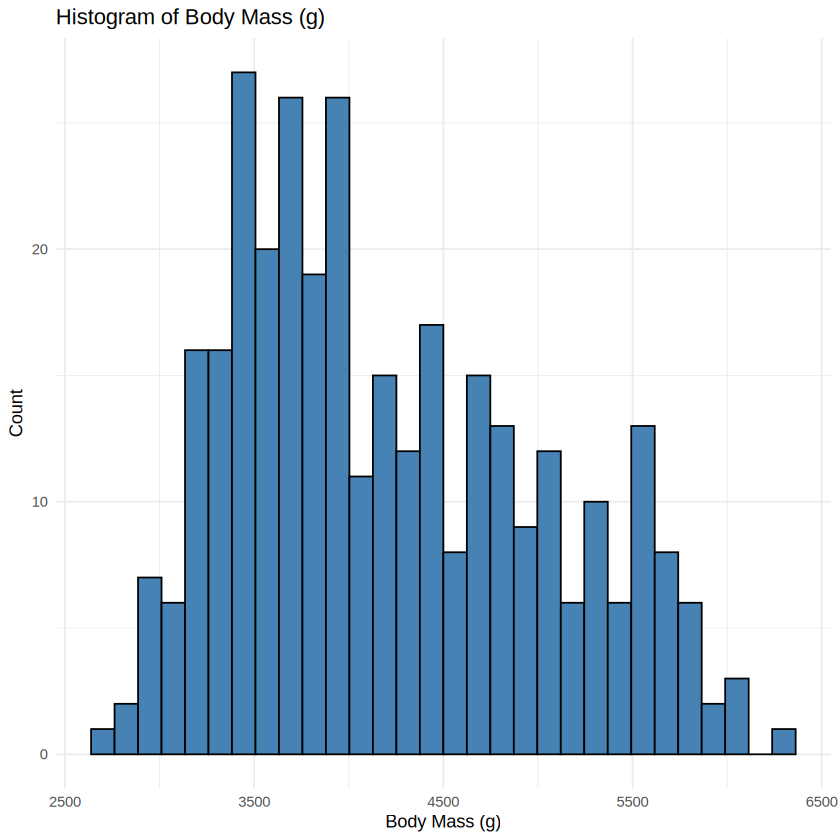

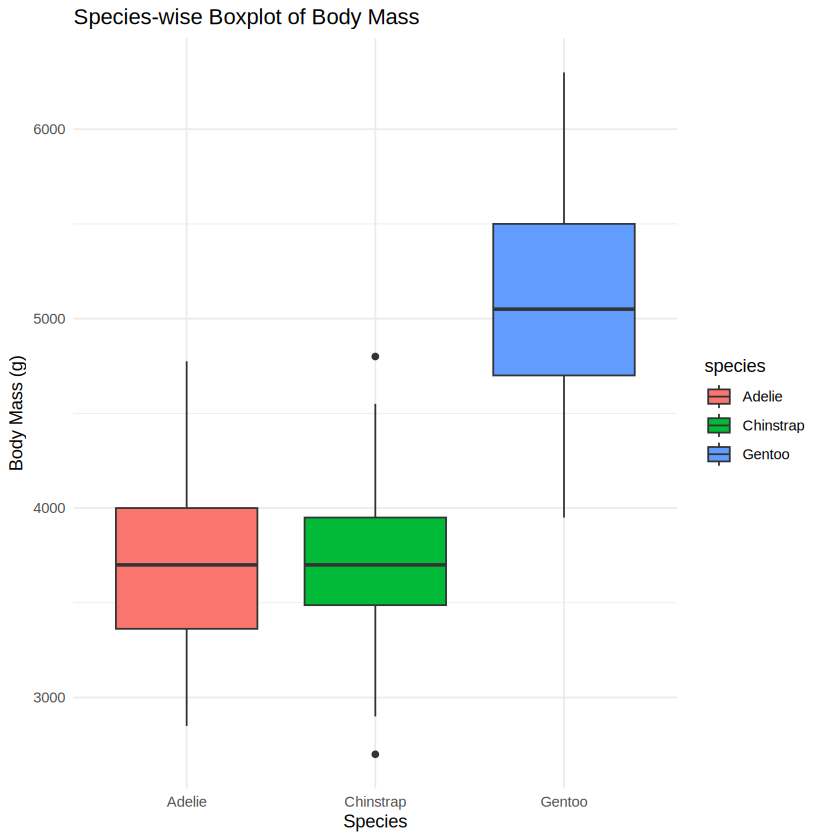

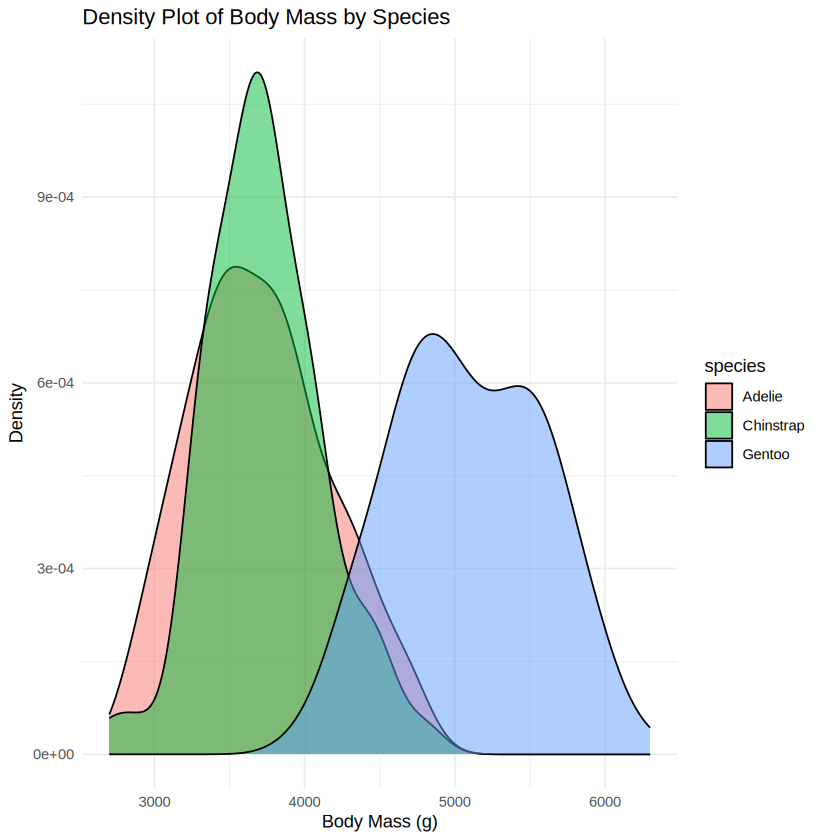

In [6]:
p1 <- ggplot(clean_penguins, aes(x = body_mass_g)) +
  geom_histogram(fill = "steelblue", color = "black", bins = 30) +
  theme_minimal() +
  labs(title = "Histogram of Body Mass (g)", x = "Body Mass (g)", y = "Count")

p2 <- ggplot(clean_penguins, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Species-wise Boxplot of Body Mass", x = "Species", y = "Body Mass (g)")

p3 <- ggplot(clean_penguins, aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.5) +
  theme_minimal() +
  labs(title = "Density Plot of Body Mass by Species", x = "Body Mass (g)", y = "Density")

print(p1)
print(p2)
print(p3)

## 2. HYPOTHESIS TESTING (MALE VS FEMALE BODY MASS)

Hypotheses

* H0: Mean body mass of male penguins = Mean body mass of female penguins
* H1: Mean body mass of male penguins != Mean body mass of female penguins

### 2.1 Normality Check: Shapiro-Wilk Test by Sex

In [7]:
cat("Shapiro-Wilk Test for Normality by Sex\n")
shapiro_sex <- clean_penguins %>%
  group_by(sex) %>%
  summarise(
    Statistic = shapiro.test(body_mass_g)$statistic,
    p_value = shapiro.test(body_mass_g)$p.value
  )
print(shapiro_sex)

Shapiro-Wilk Test for Normality by Sex
# A tibble: 2 × 3
  sex    Statistic      p_value
  <fct>      <dbl>        <dbl>
1 female     0.919 0.0000000616
2 male       0.925 0.000000123 


### 2.2 Normality Check: QQ-Plots

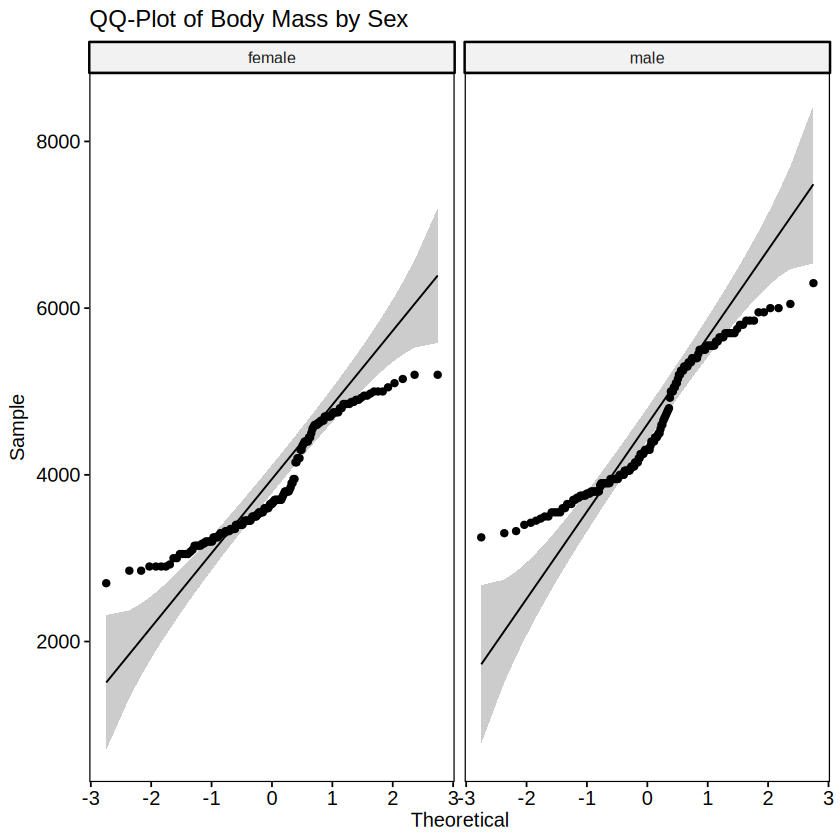

In [8]:
p_qq_sex <- ggqqplot(clean_penguins, x = "body_mass_g", facet.by = "sex",
                     title = "QQ-Plot of Body Mass by Sex")
print(p_qq_sex)

### 2.3 Independent Two-Sample T-Test

In [9]:
t_test_res <- t.test(body_mass_g ~ sex, data = clean_penguins, var.equal = FALSE)
cat("Two-Sample T-Test Results\n")
print(t_test_res)

Two-Sample T-Test Results

	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 



### 2.4 Effect Size (Cohen's d)

In [10]:
cohen_d_res <- cohensD(body_mass_g ~ sex, data = clean_penguins)
cat("\nCohen's d Effect Size:", cohen_d_res, "\n")


Cohen's d Effect Size: 0.9362048 


## 3. ONE-WAY ANOVA (BODY MASS ACROSS SPECIES)

In [11]:
# Assumption Checking: Normality within species
cat("Shapiro-Wilk Test for Normality by Species\n")
shapiro_species <- clean_penguins %>%
  group_by(species) %>%
  summarise(
    Statistic = shapiro.test(body_mass_g)$statistic,
    p_value = shapiro.test(body_mass_g)$p.value
  )
print(shapiro_species)

Shapiro-Wilk Test for Normality by Species
# A tibble: 3 × 3
  species   Statistic p_value
  <fct>         <dbl>   <dbl>
1 Adelie        0.981  0.0423
2 Chinstrap     0.984  0.561 
3 Gentoo        0.986  0.261 


### 3.1 Normality Check: QQ-Plots by species

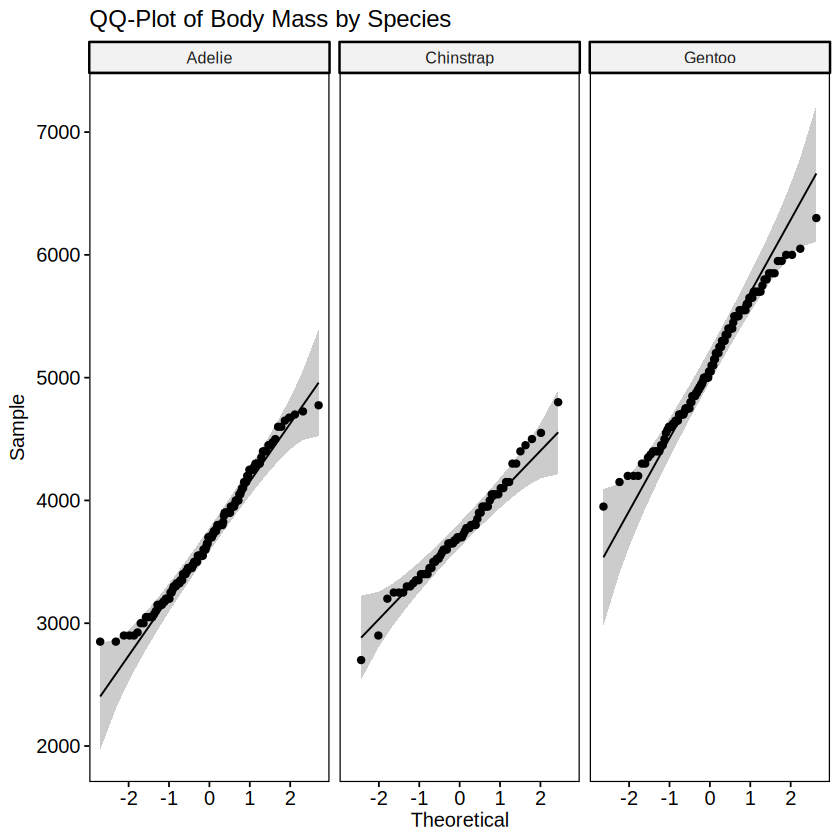

In [12]:
p_qq_species <- ggqqplot(clean_penguins, x = "body_mass_g", facet.by = "species",
                         title = "QQ-Plot of Body Mass by Species")
print(p_qq_species)

### 3.2 Homogeneity of Variance: Levene's Test

In [13]:
levene_res <- leveneTest(body_mass_g ~ species, data = clean_penguins)
cat("Levene's Test for Homogeneity of Variance\n")
print(levene_res)

Levene's Test for Homogeneity of Variance
Levene's Test for Homogeneity of Variance (center = median)
       Df F value   Pr(>F)   
group   2  5.1349 0.006367 **
      330                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


### 3.3 One-Way ANOVA

In [16]:
anova_1way <- aov(body_mass_g ~ species, data = clean_penguins)
cat("One-Way ANOVA Table\n")
anova_summary <- summary(anova_1way)
print(anova_summary)

One-Way ANOVA Table
             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


### 3.4 Post-Hoc Analysis: Tukey HSD

In [17]:
cat("Tukey HSD Post-Hoc Test\n")
tukey_res <- TukeyHSD(anova_1way)
print(tukey_res)

Tukey HSD Post-Hoc Test
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = clean_penguins)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000



## 4. NON-PARAMETRIC ANALYSIS (KRUSKAL-WALLIS TEST)

In [28]:
kw_res <- kruskal.test(body_mass_g ~ species, data = clean_penguins)
print(kw_res)


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16



> Comparison Note:

* Both One-Way ANOVA and Kruskal-Wallis test yield p-values < 0.001 leading to identical conclusions: penguin species significantly differ in body mass.

## 5. TWO-WAY ANOVA (SPECIES * SEX)

In [19]:
anova_2way <- aov(body_mass_g ~ species * sex, data = clean_penguins)
cat("Two-Way ANOVA Table\n")
print(summary(anova_2way))

Two-Way ANOVA Table
             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


## 6. ADDITIONAL ANALYSIS (FLIPPER LENGTH ACROSS SPECIES)

### 6.1 One-Way ANOVA for Flipper Length

In [20]:
anova_flipper <- aov(flipper_length_mm ~ species, data = clean_penguins)
cat("One-Way ANOVA for Flipper Length\n")
print(summary(anova_flipper))

One-Way ANOVA for Flipper Length
             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


### 6.2 Post-Hoc Tukey HSD for Flipper Length

In [21]:
cat("Tukey HSD for Flipper Length\n")
print(TukeyHSD(anova_flipper))

Tukey HSD for Flipper Length
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = clean_penguins)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0



## 7. COMPREHENSIVE VISUALIZATIONS

### 7.1 Sex-wise Boxplot of Body Mass

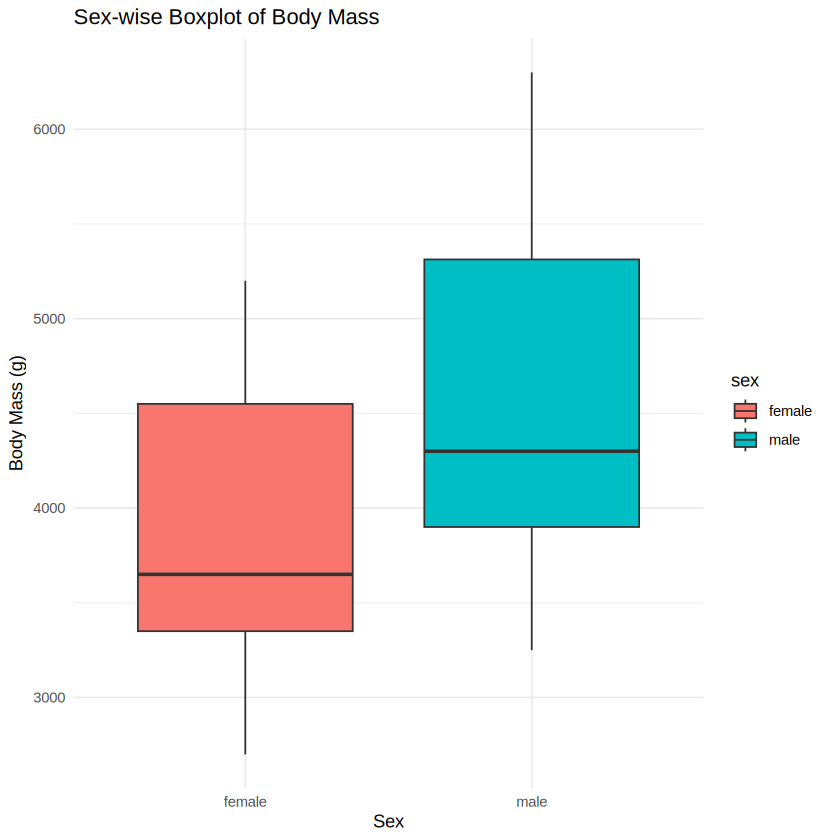

In [29]:
p_sex_box <- ggplot(clean_penguins, aes(x = sex, y = body_mass_g, fill = sex)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Sex-wise Boxplot of Body Mass", x = "Sex", y = "Body Mass (g)")

print(p_sex_box)

### 7.2 Flipper Length Comparison

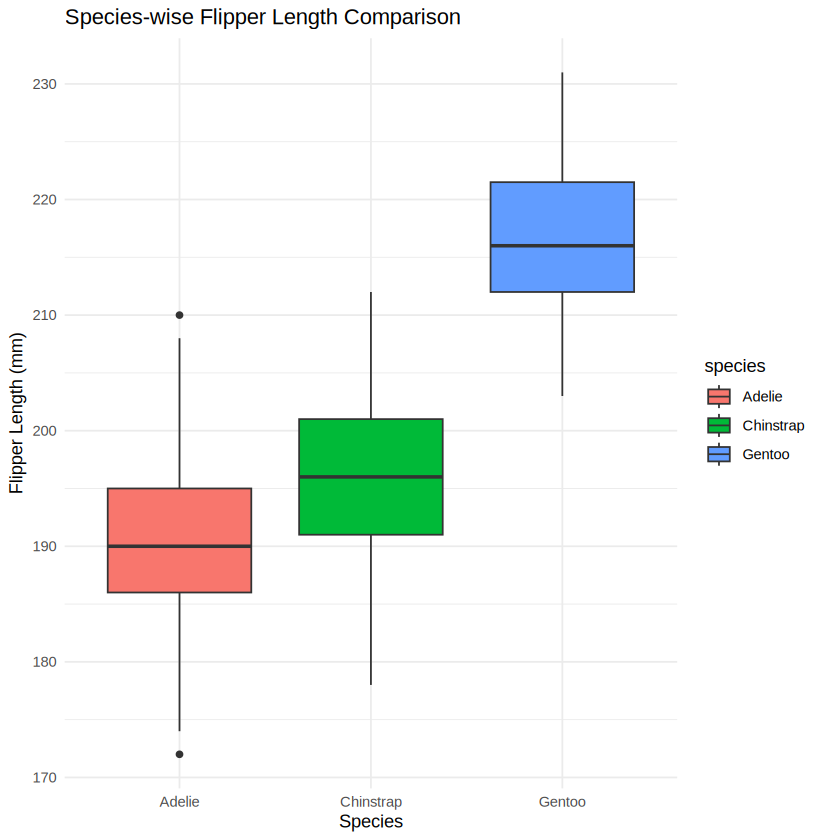

In [26]:
p_flipper_box <- ggplot(clean_penguins, aes(x = species, y = flipper_length_mm, fill = species)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Species-wise Flipper Length Comparison", x = "Species", y = "Flipper Length (mm)")

print(p_flipper_box)

### 7.3 Group Comparison Plot (Two-Way Interaction)

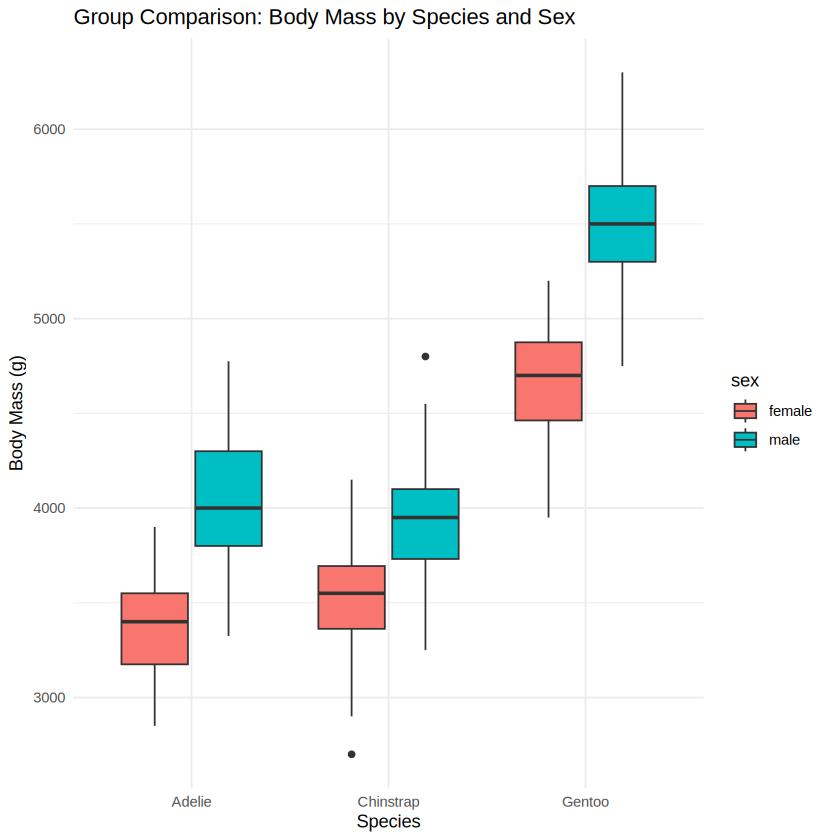

In [30]:
p_interaction <- ggplot(clean_penguins, aes(x = species, y = body_mass_g, fill = sex)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Group Comparison: Body Mass by Species and Sex", x = "Species", y = "Body Mass (g)")

print(p_interaction)